<a href="https://colab.research.google.com/github/mvu2ab/linear_models/blob/main/assignment_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Linear Models
## Do three questions.
### `! git clone https://github.com/ds4e/linearModels`

In [1]:
! git clone https://github.com/ds4e/linearModels

Cloning into 'linearModels'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43 (delta 9), reused 5 (delta 5), pack-reused 27 (from 1)
Receiving objects: 100% (43/43), 3.60 MiB | 4.75 MiB/s, done.
Resolving deltas: 100% (9/9), done.


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is "linear" if it is linear in its coefficients (parameters).

2. Difference in the mean of y between the category represented by the variable and the baseline, which is represented in the intercept.

3. Yes, not but ideally. Linear regression can be fit for binary outcomes, therefore can sort of predict probability. However, predictions can fall outside the linear model.

4. High R^2, but low validation data.

5. Multicollinearity happens when predictors are very correlated, thus making it hard to isolate the effect of one variable. It also tends to inflate the variance of coefficient estimates, leading to instability. 2SLS is used with endogeneity. First Step: Regress the endogenous predictor (x) on all exogenous instruments (z), and get predicted values (x^). Second Step: Regress the outcome y on x^, not z. This removes the problematic correlation between x and the error term.

6. Polynomials, transformations, etc.

7. Intercept: expected value of y when all x's are 0

Slope coefficient: expected change when y increases by one-unit and holds all other variables constant

Coefficient for dummy variable:
The difference in the mean of
y between the category represented by the dummy and the reference category, again holding other variables constant.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [13]:
import pandas as pd

df = pd.read_csv('./linearModels/data/Q1_clean.csv')
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')


In [15]:
avg_by_neighbourhood = df.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean().reset_index()
avg_by_neighbourhood = avg_by_neighbourhood.sort_values(by="Price", ascending=False)

most_expensive = avg_by_neighbourhood.iloc[0]
print("Most expensive neighbourhood (on average):", most_expensive["Neighbourhood "])
print("Average price:", most_expensive["Price"])



Most expensive neighbourhood (on average): Manhattan
Average price: 183.6642863215166


<ipython-input-24-098a6f728542>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Log Price"] = np.log1p(df_filtered["Price"])


Text(0.5, 1.0, 'Kernel Density Plot of Log Price by Neighbourhood')

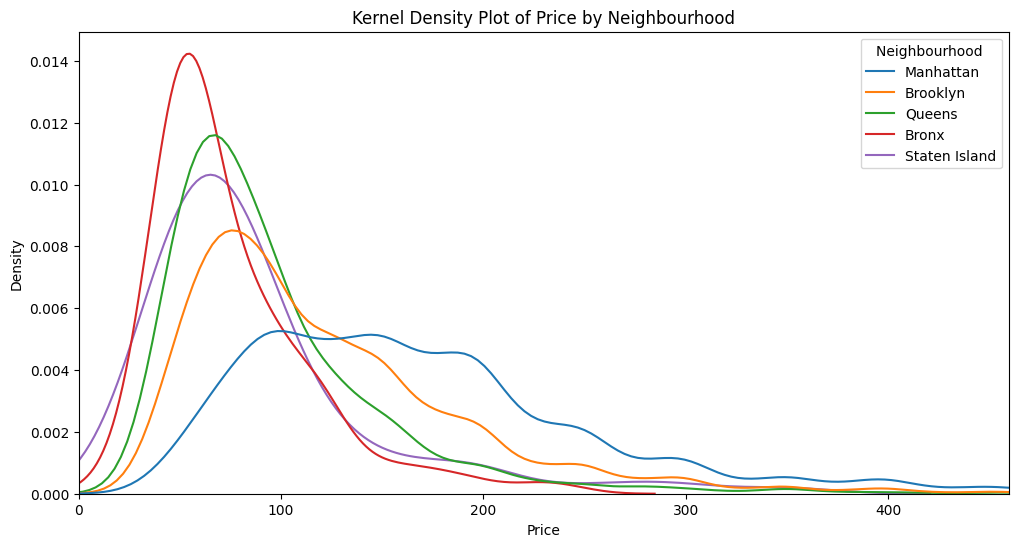

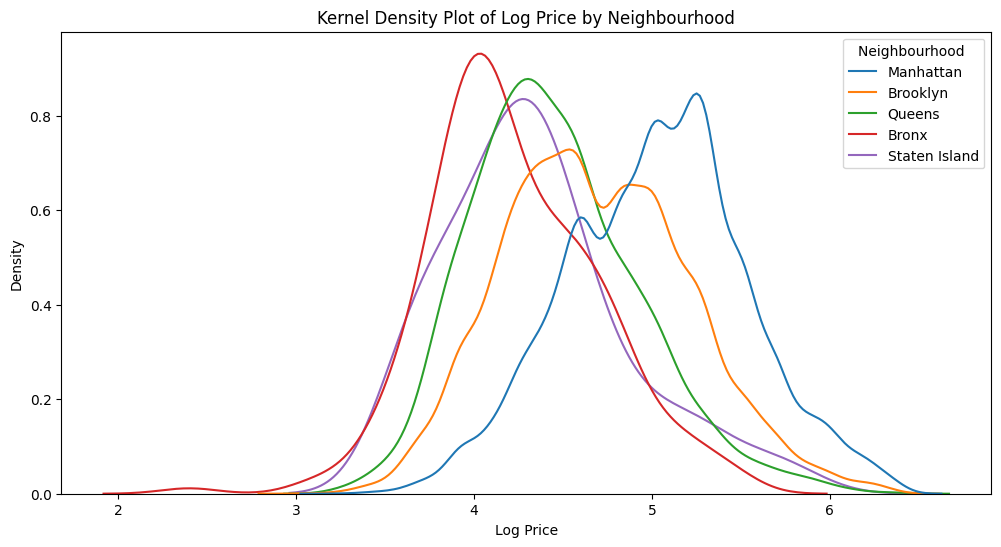

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[df['Price'] < df['Price'].quantile(0.99)]

df_filtered["Log Price"] = np.log1p(df_filtered["Price"])

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_filtered, x="Price", hue="Neighbourhood ", common_norm=False)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlim(0, df_filtered['Price'].quantile(0.99))

# Plot kernel density for log prices
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_filtered, x="Log Price", hue="Neighbourhood ", common_norm=False)
plt.title("Kernel Density Plot of Log Price by Neighbourhood")




In [19]:
import statsmodels.api as sm

neighbourhood_dummies = pd.get_dummies(df['Neighbourhood '], drop_first=False)

model = sm.OLS(df['Price'], neighbourhood_dummies).fit()

print(model.summary())
coefficients = model.params


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 01 May 2025   Prob (F-statistic):          4.43e-226
Time:                        23:10:05   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [21]:
comparison = comparison[[comparison.columns[0],comparison.columns[1], comparison.columns[-1]]] # selecting 3 columns for comparison
comparison.columns = ['Neighbourhood','Avg Price', 'Regression Coef'] # renaming the columns appropriately

print(comparison)

               Neighbourhood   Avg Price  Regression Coef
2                  Manhattan  183.664286              NaN
4              Staten Island  146.166667              NaN
1                   Brooklyn  127.747378              NaN
3                     Queens   96.857233              NaN
0                      Bronx   75.276498              NaN
Bronx                    NaN         NaN        75.276498
Brooklyn                 NaN         NaN       127.747378
Manhattan                NaN         NaN       183.664286
Queens                   NaN         NaN        96.857233
Staten Island            NaN         NaN       146.166667


The regression coef exactly match the mean prices for each neighborhood. There is no intercept in the model, so each group has its own "mean line"

In [26]:
import statsmodels.api as sm
import pandas as pd

neighbourhood_dummies = pd.get_dummies(df['Neighbourhood '], drop_first=False)

model = sm.OLS(df['Price'], neighbourhood_dummies).fit()

print(model.summary())
coefficients = model.params



                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 01 May 2025   Prob (F-statistic):          4.43e-226
Time:                        23:27:01   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [32]:
from sklearn.linear_model import LinearRegression # Import LinearRegression from sklearn.linear_model

neighbourhood_dummies_with_intercept = pd.get_dummies(df['Neighbourhood '], drop_first=True)

lm_with_intercept = LinearRegression()
lm_with_intercept.fit(neighbourhood_dummies_with_intercept, df['Price'])

intercept = lm_with_intercept.intercept_
coefficients = pd.Series(lm_with_intercept.coef_, index=neighbourhood_dummies_with_intercept.columns)

print(f"Intercept: {intercept:.2f}")
print("Coefficients (difference from baseline):")
print(coefficients)

Intercept: 75.28
Coefficients (difference from baseline):
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


This is different because you drop one dummy variable when including intercept to avoid multicollinearity. Intercept is average prince of the reference (dropped) neighborhood. Each coefficient shows how much more or less expensive a neighbourhood is compared to the reference group. Add each coefficient to the intercept to recover the average price for that neighbourhood.

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = pd.get_dummies(train_df[['Review Scores Rating', 'Neighbourhood ']], drop_first=True)
X_train = sm.add_constant(X_train)
X_train = X_train.astype(float)
y_train = train_df['Price']


X_test = pd.get_dummies(test_df[['Review Scores Rating', 'Neighbourhood ']], drop_first=True)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.astype(float)
y_test = test_df['Price']


model = sm.OLS(y_train, X_train).fit()


y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
coef_rating = model.params['Review Scores Rating']


most_expensive_type = df.groupby("Property Type")["Price"].mean().idxmax()
most_expensive_price = df.groupby("Property Type")["Price"].mean().max()


print("R² on test set:", r2)
print("RMSE on test set:", rmse)
print("Coefficient on Review Scores Rating:", coef_rating)
print("Most expensive property type:", most_expensive_type, "with average price:", most_expensive_price)


R² on test set: 0.045925883817350965
RMSE on test set: 140.91821103729345
Coefficient on Review Scores Rating: 1.2118517840632361
Most expensive property type: Condominium with average price: 241.22916666666666


In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


X_train = pd.get_dummies(train_df[['Review Scores Rating', 'Neighbourhood ', 'Property Type']], drop_first=True)
X_train = sm.add_constant(X_train)
X_train = X_train.astype(float)

y_train = train_df['Price']


X_test = pd.get_dummies(test_df[['Review Scores Rating', 'Neighbourhood ', 'Property Type']], drop_first=True)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.astype(float)

y_test = test_df['Price']


model = sm.OLS(y_train, X_train).fit()


y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
coef_rating = model.params['Review Scores Rating']

most_expensive_type = df.groupby("Property Type")["Price"].mean().idxmax()
most_expensive_price = df.groupby("Property Type")["Price"].mean().max()


print("R² on test set:", r2)
print("RMSE on test set:", rmse)
print("Coefficient on Review Scores Rating:", coef_rating)
print("Most expensive property type:", most_expensive_type, "with average price:", most_expensive_price)


R² on test set: 0.054242713551245325
RMSE on test set: 140.30266238276283
Coefficient on Review Scores Rating: 1.2010106602298567
Most expensive property type: Condominium with average price: 241.22916666666666


If it changes from part 4 to 5 it means that Review Scoring Rating is correlated with other variables.

**Q7.** In class, we showed that for the single linear regression model,
\begin{alignat*}{3}
a^* &=& \bar{y} \\
b^* &=& \dfrac{\sum_{i=1}^N(y_i - \bar{y})(x_i-\bar{x})}{\sum_{i=1}^N (x_i-\bar{x})^2},
\end{alignat*}

1. When will $b^*$ be large or small, depending on the relationship between $X$ and $Y$ and the variance of $X$?
2. Suppose you have measurement error in $X$ which artificially inflates its variance (e.g. bad data cleaning). We'll model this as saying the "real" value of $X$ for observation $i$ is $z_i$, but we observe $x_i = z_i + n_i$, where $n_i$ is the added noise. Does this affect the intercept of the regression? What happens to the $b^*$ coefficient relative to a noise-less model? How will affect your ability to predict? (This phenomenon is called **attenuation**.)
3. Suppose the noise $n_i$ is independent of $z_i$ and $y_i$, so that (approximately)
$$
\dfrac{1}{N} \sum_{i=1}^N (y_i - \bar{y})(n_i - \bar{n}) =0, \quad \dfrac{1}{N} \sum_{i=1}^N (z_i - \bar{z})(n_i - \bar{n}) =0.
$$
and that the mean of the bias is zero, so that
$$
\dfrac{1}{N} \sum_{i=1}^N n_i = 0.
$$
In this case, the noise $n_i$ is zero on average and independent of the values of $x_i$ and $y_i$: It's just measurement error or lazy data cleaning.
Explain the intuition of your result.

4. How does attenuation factor into the cost-benefit analysis of gathering higher quality data or cleaning it more carefully?

1. b* will be large when the covariance between X and Y is large, the numerator will be large, thus making b* large. When the covaraince between X and Y is small, b* will be small.

2. Measurement error will not directly impact the intercept. Measurement error will reduce b* due to the fact that increased noise increases the variance of X which decreases validiity of the slope. Prediction accuracy will decrease.

3. The error will not directly affect the regression relationship.

4. Cleaner data improves estimates and increases prediction power. While higher quality/better data may be more costly, it is more reliable in the end.